In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Input
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import joblib

In [2]:
df=pd.read_csv("synthetic_american_put_dataset.csv")
df.head()

,S0,K,T,r,sigma,Put_Price
0,89.963210,83.694834,1.702111,0.000188,0.332312,11.968496
1,136.057145,82.430149,1.014308,0.095998,0.310789,0.354892
2,118.559515,104.167678,0.431158,0.053532,0.240415,1.579463
3,107.892679,118.644653,1.486451,0.070040,0.297285,17.218931
4,72.481491,100.108852,0.866422,0.091260,0.246039,27.627361


In [3]:
X=df.drop("Put_Price",axis=1)
y=df["Put_Price"]

In [4]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.20,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.50,random_state=42)

print("Training Set :",X_train.shape)
print("Validation Set :",X_val.shape)
print("Testing Set :",X_test.shape)

Training Set : (20000, 5)
Validation Set : (2500, 5)
Testing Set : (2500, 5)


In [5]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

In [6]:
model=Sequential()
model.add(Dense(128,input_dim=X_train.shape[1],activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1))

In [7]:
model.compile(optimizer=Adam(learning_rate=0.001),loss="mse",metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping=EarlyStopping(monitor="val_loss",patience=20,restore_best_weights=True)

reduce_lr=ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=10,min_lr=1e-6)

In [9]:
history=model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56.0669 - mae: 3.5139 - val_loss: 1.2056 - val_mae: 0.8140 - learning_rate: 0.0010
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8184 - mae: 0.6516 - val_loss: 0.4247 - val_mae: 0.4740 - learning_rate: 0.0010
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2698 - mae: 0.3786 - val_loss: 0.1829 - val_mae: 0.3131 - learning_rate: 0.0010
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1330 - mae: 0.2731 - val_loss: 0.1125 - val_mae: 0.2597 - learning_rate: 0.0010
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0881 - mae: 0.2247 - val_loss: 0.0692 - val_mae: 0.2001 - learning_rate: 0.0010
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0627 - mae: 0.1902 - val_loss: 0.0624 - val_mae: 0.1901 - learning_rate: 0.0010
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0507 - mae: 0.1711 - val_loss: 0.0438 - val_mae: 0.1607 - learning_rate: 0.001

In [10]:
loss,mae=model.evaluate(X_test,y_test,verbose=0)

print("Test Loss :",loss)
print("Test MAE :",mae)

Test Loss : 0.0019626531284302473
Test MAE : 0.031422123312950134


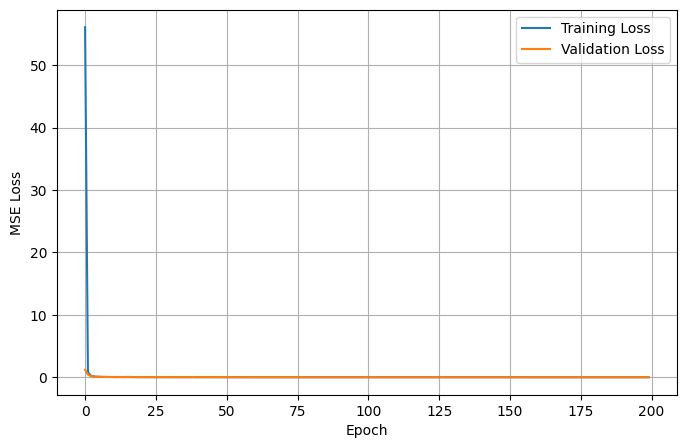

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.savefig("learning_curve.png",dpi=300,bbox_inches="tight")
plt.show()

In [12]:
y_pred=model.predict(X_test,verbose=0).flatten()

In [20]:
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

mape=np.mean(np.abs((y_test-y_pred)/(np.abs(y_test)+1e-8)))*100

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

max_error=np.max(np.abs(y_test-y_pred))
print(f"Max Absolute Error : {max_error:.6f}")

MAE  : 0.031422
RMSE : 0.044302
R²   : 0.999989
Max Absolute Error : 0.434644


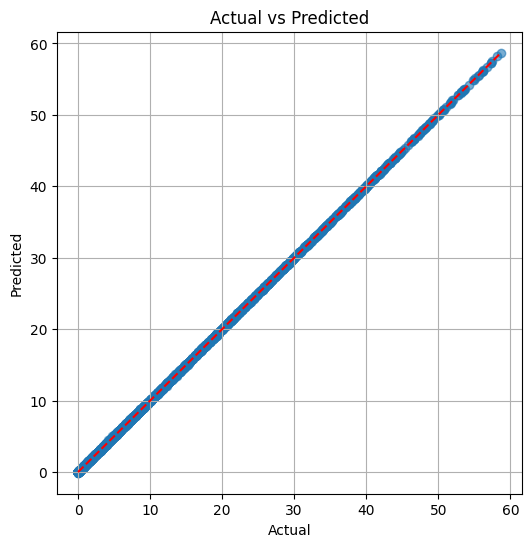

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.savefig("actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

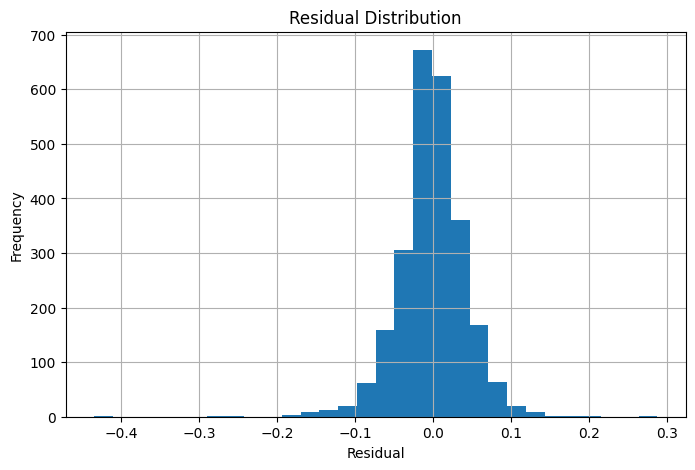

In [16]:
plt.figure(figsize=(8,5))
plt.hist(residuals,bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.savefig("residual_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [19]:
model.save("american_put_pricing_model.keras")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [21]:
results=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
results["Absolute_Error"]=np.abs(results["Actual"]-results["Predicted"])
results.sort_values("Absolute_Error",ascending=False).head(10)

,Actual,Predicted,Absolute_Error
5732,4.104398,4.539042,0.434644
5001,4.745776,5.035478,0.289701
9655,13.751834,13.464457,0.287377
16403,12.337801,12.071216,0.266586
11056,4.376589,4.640084,0.263495
5068,19.266735,19.060907,0.205828
15318,4.053020,3.847204,0.205816
23797,3.750121,3.939250,0.189130
752,14.311544,14.126458,0.185086
8604,7.243555,7.424785,0.181230


In [23]:
df.iloc[5732]

S0           112.465661
K            109.193133
T              0.074543
r              0.038751
sigma          0.474058
Put_Price      4.104398
Name: 5732, dtype: float64

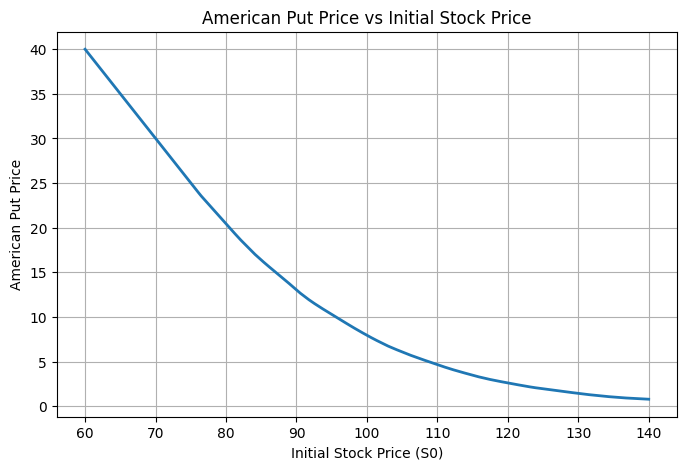

In [24]:
S0=np.linspace(60,140,200)
test=pd.DataFrame({"S0":S0,"K":100,"T":1.0,"r":0.05,"sigma":0.25})
put_price=model.predict(scaler.transform(test),verbose=0).flatten()

plt.figure(figsize=(8,5))
plt.plot(S0,put_price,linewidth=2)
plt.xlabel("Initial Stock Price (S0)")
plt.ylabel("American Put Price")
plt.title("American Put Price vs Initial Stock Price")
plt.grid(True)
plt.savefig("put_price_vs_spot_price.png",dpi=300,bbox_inches="tight")
plt.show()